In [ ]:
# MSc AI Fundamentals – Maze Pathfinding Using Logical Inference

## Problem Statement
Find a path from **(0,0)** to **(4,5)** in a **5 × 6** grid maze.  
Permitted moves: **Left, Right, Up, Down**.  
Obstacles (red nodes): `(0,1) (2,1) (2,3) (3,1) (3,4) (4,4)`  
Boundaries act as walls.

## Approach & Criteria
| # | Criterion | Approach |
|---|-----------|----------|
| 1 | **Data structure representation** | Nodes as `(row, col)` tuples; obstacles in a `set`; adjacency via move vectors in a `dict`; parent map in a `dict` for path reconstruction |
| 2 | **Success criteria** | Goal is reached when the search frontier expands to node `(4, 5)` |
| 3 | **Blind search algorithms** | **BFS** (Breadth-First Search) and **DFS** (Depth-First Search) — both are uninformed algorithms |
| 4 | **Cost calculation** | Each move costs 1 unit; total cost = number of edges in the solution path |
| 5 | **Visualisation** | Matplotlib grid plots: maze layout, solution paths, BFS vs DFS comparison, and step-by-step state-space exploration |

## 1. Maze Representation Using Python Data Structures
The state space is represented **implicitly** using lightweight Python data structures — no explicit adjacency list is needed.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 1. MAZE REPRESENTATION
# ═══════════════════════════════════════════════════════════════════════
#
# Data structures chosen:
#   • Nodes     → tuples (row, col)         — immutable, hashable, lightweight
#   • Grid size → two integers (ROWS, COLS) — define boundary walls
#   • Obstacles → set of tuples             — O(1) membership test
#   • Moves     → dict {name: (dr, dc)}     — maps direction labels to offsets
#   • Parent    → dict {node: parent_node}  — enables path reconstruction
#
# These structures together implicitly define the state space (graph)
# without needing to build an explicit adjacency list.

from collections import deque

# ── Grid dimensions ──────────────────────────────────────────────────
ROWS, COLS = 5, 6

# ── Start and goal nodes ─────────────────────────────────────────────
START = (0, 0)
GOAL  = (4, 5)

# ── Obstacles stored in a set for O(1) look-up ──────────────────────
OBSTACLES = {(0, 1), (2, 1), (2, 3), (3, 1), (3, 4), (4, 4)}

# ── Four permitted moves (direction name → row/col offset) ──────────
MOVES = {
    "UP":    (-1,  0),
    "DOWN":  ( 1,  0),
    "LEFT":  ( 0, -1),
    "RIGHT": ( 0,  1),
}

# ── Success criterion ────────────────────────────────────────────────
# The search succeeds when the algorithm discovers the GOAL node.

# ═══════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS  (used by both BFS and DFS)
# ═══════════════════════════════════════════════════════════════════════

def is_valid(pos):
    """Return True if `pos` is inside the grid and not an obstacle."""
    r, c = pos
    return 0 <= r < ROWS and 0 <= c < COLS and pos not in OBSTACLES

def reconstruct_path(parent, move_taken, goal):
    """Walk backwards from goal to start using parent pointers."""
    path, directions = [], []
    node = goal
    while node is not None:
        path.append(node)
        if move_taken[node] is not None:
            directions.append(move_taken[node])
        node = parent[node]
    path.reverse()
    directions.reverse()
    return path, directions

# ── Summary ──────────────────────────────────────────────────────────
print("Maze parameters loaded.")
print(f"  Grid size : {ROWS}×{COLS}  ({ROWS * COLS} nodes total)")
print(f"  Start     : {START}")
print(f"  Goal      : {GOAL}")
print(f"  Obstacles : {sorted(OBSTACLES)}")
print(f"  Free nodes: {ROWS * COLS - len(OBSTACLES)}")
print(f"\nData structures:")
print(f"  Nodes     → tuple   e.g. {START}")
print(f"  Obstacles → set     {type(OBSTACLES).__name__} (size {len(OBSTACLES)})")
print(f"  Moves     → dict    {list(MOVES.keys())}")
print(f"\nSuccess criterion: search terminates when GOAL {GOAL} is reached.")

Maze parameters loaded.
  Grid size : 5×6  (30 nodes total)
  Start     : (0, 0)
  Goal      : (4, 5)
  Obstacles : [(0, 1), (2, 1), (2, 3), (3, 1), (3, 4), (4, 4)]
  Free nodes: 24

Data structures:
  Nodes     → tuple   e.g. (0, 0)
  Obstacles → set     set (size 6)
  Moves     → dict    ['UP', 'DOWN', 'LEFT', 'RIGHT']

Success criterion: search terminates when GOAL (4, 5) is reached.


## 2. Breadth-First Search (BFS) — Blind Algorithm #1
BFS is a **blind (uninformed)** search algorithm that explores the state space **level by level** using a **FIFO queue**.  
It guarantees the **shortest path** in an unweighted graph because it examines all nodes at depth $d$ before any node at depth $d+1$.

In [44]:
# ── 2. Blind Search Algorithm: Breadth-First Search (BFS) ────────────
#
# BFS is a *blind* (uninformed) search algorithm because it explores the
# state space without any domain-specific heuristic — it only uses the
# structure of the graph (adjacent nodes).
#
# Properties of BFS:
#   • Complete  — guaranteed to find a solution if one exists
#   • Optimal   — finds the shortest path in an unweighted graph
#   • Time      — O(V + E) where V = nodes, E = edges
#   • Space     — O(V)     (stores the frontier queue + visited set)
#
# Implementation via forward-chaining logical inference:
#   Knowledge Base (KB):
#       Fact 1 : reachable(START)
#   Inference Rule:
#       IF reachable(X) AND valid(Y) AND adjacent(X, Y)
#       THEN reachable(Y)
#   The rule is applied level-by-level (BFS order) until reachable(GOAL).

from collections import deque

def is_valid(pos):
    """Check whether a position is inside the grid and not an obstacle."""
    r, c = pos
    return 0 <= r < ROWS and 0 <= c < COLS and pos not in OBSTACLES

def bfs_logical_inference(start, goal):
    """
    Breadth-First Search implemented as forward-chaining logical inference.

    Returns
    -------
    found        : bool  — whether the goal is reachable
    parent       : dict  — maps each visited node to its predecessor
    move_taken   : dict  — maps each visited node to the direction used
    inference_log: list  — step-by-step record of every inference
    nodes_explored: int  — total number of nodes expanded (state-space cost)
    """
    # --- Knowledge Base initialisation ---
    kb_reachable = {start}          # set of known-reachable nodes (facts)
    parent       = {start: None}    # for path reconstruction
    move_taken   = {start: None}    # direction label per step
    inference_log = []              # record every inference step

    queue = deque([start])          # FIFO queue  ← key BFS data structure
    nodes_explored = 0

    while queue:
        current = queue.popleft()   # expand the oldest node first (BFS)
        nodes_explored += 1
        inferred_this_step = []

        for direction, (dr, dc) in MOVES.items():
            neighbor = (current[0] + dr, current[1] + dc)

            # Apply inference rule: is neighbor valid AND not yet in KB?
            if is_valid(neighbor) and neighbor not in kb_reachable:
                # Derive new fact: reachable(neighbor)
                kb_reachable.add(neighbor)
                parent[neighbor]     = current
                move_taken[neighbor] = direction
                queue.append(neighbor)
                inferred_this_step.append((neighbor, direction))

                # ── Success criterion check ──
                if neighbor == goal:
                    inference_log.append((nodes_explored, current, inferred_this_step))
                    return True, parent, move_taken, inference_log, nodes_explored

        if inferred_this_step:
            inference_log.append((nodes_explored, current, inferred_this_step))

    return False, parent, move_taken, inference_log, nodes_explored

# ── Run BFS ──
found, parent, move_taken, log, nodes_explored = bfs_logical_inference(START, GOAL)

print(f"Algorithm        : Breadth-First Search (blind / uninformed)")
print(f"Goal reachable   : {found}")
print(f"Nodes explored   : {nodes_explored}")

Algorithm        : Breadth-First Search (blind / uninformed)
Goal reachable   : True
Nodes explored   : 23


In [45]:
# ── 3. Print the Inference Log ────────────────────────────────────────
print("=" * 60)
print("       FORWARD-CHAINING INFERENCE LOG")
print("=" * 60)

for step_num, current_node, inferences in log:
    print(f"\nStep {step_num}: Expanding reachable({current_node})")
    for (neighbor, direction) in inferences:
        print(f"  Rule applied: reachable{current_node} ∧ adjacent{current_node, neighbor}"
              f" → reachable{neighbor}  [move: {direction}]")

print("\n" + "=" * 60)

       FORWARD-CHAINING INFERENCE LOG

Step 1: Expanding reachable((0, 0))
  Rule applied: reachable(0, 0) ∧ adjacent((0, 0), (1, 0)) → reachable(1, 0)  [move: DOWN]

Step 2: Expanding reachable((1, 0))
  Rule applied: reachable(1, 0) ∧ adjacent((1, 0), (2, 0)) → reachable(2, 0)  [move: DOWN]
  Rule applied: reachable(1, 0) ∧ adjacent((1, 0), (1, 1)) → reachable(1, 1)  [move: RIGHT]

Step 3: Expanding reachable((2, 0))
  Rule applied: reachable(2, 0) ∧ adjacent((2, 0), (3, 0)) → reachable(3, 0)  [move: DOWN]

Step 4: Expanding reachable((1, 1))
  Rule applied: reachable(1, 1) ∧ adjacent((1, 1), (1, 2)) → reachable(1, 2)  [move: RIGHT]

Step 5: Expanding reachable((3, 0))
  Rule applied: reachable(3, 0) ∧ adjacent((3, 0), (4, 0)) → reachable(4, 0)  [move: DOWN]

Step 6: Expanding reachable((1, 2))
  Rule applied: reachable(1, 2) ∧ adjacent((1, 2), (0, 2)) → reachable(0, 2)  [move: UP]
  Rule applied: reachable(1, 2) ∧ adjacent((1, 2), (2, 2)) → reachable(2, 2)  [move: DOWN]
  Rule appli

## 4. Depth-First Search (DFS) — Second Blind Algorithm
DFS is another **blind (uninformed)** search algorithm. Unlike BFS which uses a **FIFO queue**, DFS uses a **LIFO stack** — it dives deep into one branch before backtracking.

| Property | BFS | DFS |
|----------|-----|-----|
| Data structure | FIFO Queue (`deque`) | LIFO Stack (`list`) |
| Completeness | ✅ Yes | ✅ Yes (finite graphs) |
| Optimality | ✅ Shortest path | ❌ Not guaranteed |
| Time complexity | O(V + E) | O(V + E) |
| Space complexity | O(V) | O(V) |

In [47]:
# ── 4. Depth-First Search (DFS) Implementation ──────────────────────
#
# DFS is a *blind* (uninformed) search that uses a LIFO stack.
# It explores as deep as possible along each branch before backtracking.
# Unlike BFS, DFS does NOT guarantee the shortest path.

def dfs_search(start, goal):
    """
    Depth-First Search using an explicit stack.

    Returns
    -------
    found          : bool
    parent         : dict  — maps each visited node to its predecessor
    move_taken     : dict  — direction used to reach each node
    exploration_log: list  — ordered list of nodes as they were explored
    nodes_explored : int   — total nodes expanded
    """
    visited    = {start}
    parent     = {start: None}
    move_taken = {start: None}
    exploration_log = [start]

    stack = [start]               # LIFO stack ← key DFS data structure
    nodes_explored = 0

    while stack:
        current = stack.pop()     # expand the most-recent node (DFS)
        nodes_explored += 1

        # ── Success criterion check ──
        if current == goal:
            return True, parent, move_taken, exploration_log, nodes_explored

        for direction, (dr, dc) in MOVES.items():
            neighbor = (current[0] + dr, current[1] + dc)

            if is_valid(neighbor) and neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor]     = current
                move_taken[neighbor] = direction
                stack.append(neighbor)
                exploration_log.append(neighbor)

    return False, parent, move_taken, exploration_log, nodes_explored

# ── Run DFS ──
dfs_found, dfs_parent, dfs_move_taken, dfs_exploration_log, dfs_nodes_explored = dfs_search(START, GOAL)

print(f"Algorithm        : Depth-First Search (blind / uninformed)")
print(f"Goal reachable   : {dfs_found}")
print(f"Nodes explored   : {dfs_nodes_explored}")

Algorithm        : Depth-First Search (blind / uninformed)
Goal reachable   : True
Nodes explored   : 10


In [48]:
# ── 5. BFS vs DFS — Path Comparison ──────────────────────────────────

# Reconstruct BFS path (already computed, but rename for clarity)
bfs_path, bfs_directions = reconstruct_path(parent, move_taken, GOAL)
bfs_cost = len(bfs_path) - 1

# Reconstruct DFS path
dfs_path, dfs_directions = reconstruct_path(dfs_parent, dfs_move_taken, GOAL)
dfs_cost = len(dfs_path) - 1

free_nodes = ROWS * COLS - len(OBSTACLES)

# ── Print BFS solution ──
print("=" * 62)
print("  BFS SOLUTION  (Breadth-First Search)")
print("=" * 62)
for i, node in enumerate(bfs_path):
    tag = "← START" if i == 0 else ("← GOAL" if i == len(bfs_path)-1 else "")
    move = f"(move: {bfs_directions[i-1]})" if i > 0 else ""
    print(f"  {i:>2}. {str(node):<10} {move:<20} {tag}")
print(f"\n  Path : {' → '.join(str(p) for p in bfs_path)}")
print(f"  Cost : {bfs_cost} moves")
print(f"  Nodes explored: {nodes_explored}")

# ── Print DFS solution ──
print(f"\n{'=' * 62}")
print("  DFS SOLUTION  (Depth-First Search)")
print("=" * 62)
for i, node in enumerate(dfs_path):
    tag = "← START" if i == 0 else ("← GOAL" if i == len(dfs_path)-1 else "")
    move = f"(move: {dfs_directions[i-1]})" if i > 0 else ""
    print(f"  {i:>2}. {str(node):<10} {move:<20} {tag}")
print(f"\n  Path : {' → '.join(str(p) for p in dfs_path)}")
print(f"  Cost : {dfs_cost} moves")
print(f"  Nodes explored: {dfs_nodes_explored}")

# ── Comparison table ──
print(f"\n{'=' * 62}")
print("  BFS vs DFS — COMPARISON")
print(f"{'=' * 62}")
print(f"  {'Metric':<30} {'BFS':>10} {'DFS':>10}")
print(f"  {'─' * 50}")
print(f"  {'Path cost (moves)':<30} {bfs_cost:>10} {dfs_cost:>10}")
print(f"  {'Nodes in path':<30} {len(bfs_path):>10} {len(dfs_path):>10}")
print(f"  {'Nodes explored':<30} {nodes_explored:>10} {dfs_nodes_explored:>10}")
print(f"  {'Search efficiency':<30} {nodes_explored/free_nodes:>9.1%} {dfs_nodes_explored/free_nodes:>9.1%}")
print(f"  {'Optimal (shortest path)?':<30} {'✓ Yes':>10} {'✗ No':>10}")
print(f"  {'Data structure':<30} {'Queue':>10} {'Stack':>10}")
print(f"  {'─' * 50}")

if bfs_cost < dfs_cost:
    print(f"\n  ➤ BFS found a SHORTER path ({bfs_cost} vs {dfs_cost} moves).")
    print(f"    BFS is optimal for unweighted graphs.")
elif bfs_cost == dfs_cost:
    print(f"\n  ➤ Both found equal-length paths ({bfs_cost} moves).")
    print(f"    But BFS guarantees this; DFS was lucky.")
else:
    print(f"\n  ➤ DFS found a shorter path this time, but this is not guaranteed.")
print(f"  ➤ DFS explored {dfs_nodes_explored} nodes vs BFS {nodes_explored} nodes.")
print("=" * 62)

  BFS SOLUTION  (Breadth-First Search)
   0. (0, 0)                          ← START
   1. (1, 0)     (move: DOWN)         
   2. (1, 1)     (move: RIGHT)        
   3. (1, 2)     (move: RIGHT)        
   4. (1, 3)     (move: RIGHT)        
   5. (1, 4)     (move: RIGHT)        
   6. (2, 4)     (move: DOWN)         
   7. (2, 5)     (move: RIGHT)        
   8. (3, 5)     (move: DOWN)         
   9. (4, 5)     (move: DOWN)         ← GOAL

  Path : (0, 0) → (1, 0) → (1, 1) → (1, 2) → (1, 3) → (1, 4) → (2, 4) → (2, 5) → (3, 5) → (4, 5)
  Cost : 9 moves
  Nodes explored: 23

  DFS SOLUTION  (Depth-First Search)
   0. (0, 0)                          ← START
   1. (1, 0)     (move: DOWN)         
   2. (1, 1)     (move: RIGHT)        
   3. (1, 2)     (move: RIGHT)        
   4. (1, 3)     (move: RIGHT)        
   5. (1, 4)     (move: RIGHT)        
   6. (1, 5)     (move: RIGHT)        
   7. (2, 5)     (move: DOWN)         
   8. (3, 5)     (move: DOWN)         
   9. (4, 5)     (move: DO

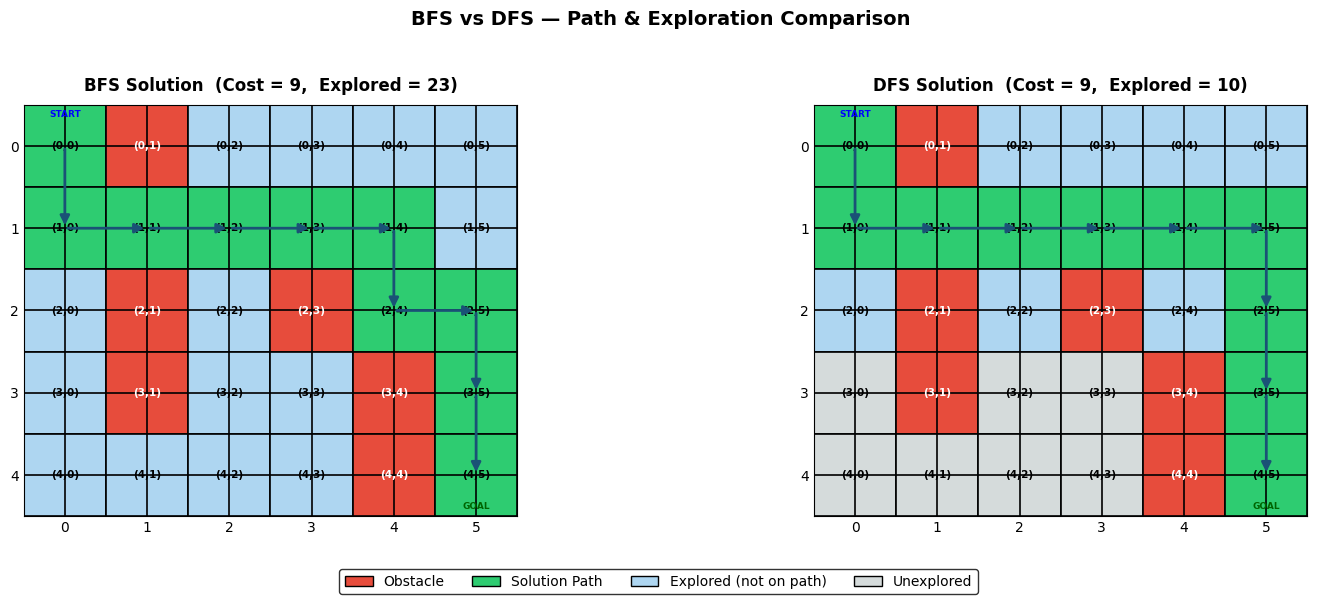

Comparison figure saved as bfs_vs_dfs_comparison.png


In [49]:
# ── 6. BFS vs DFS — Side-by-Side Visualisation ───────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_maze_compare(ax, title, path_cells, path_arrows, explored_cells):
    """Draw a single maze panel for comparison."""
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(ROWS - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.tick_params(length=0)
    ax.grid(True, linewidth=1.2, color="black")

    path_s = set(path_cells) if path_cells else set()
    expl_s = set(explored_cells) if explored_cells else set()

    for r in range(ROWS):
        for c in range(COLS):
            pos = (r, c)
            if pos in OBSTACLES:
                color = "#e74c3c"
            elif pos in path_s:
                color = "#2ecc71"
            elif pos in expl_s:
                color = "#aed6f1"
            else:
                color = "#d5dbdb"
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                 facecolor=color, edgecolor="black", lw=1.2)
            ax.add_patch(rect)
            fontc = "white" if pos in OBSTACLES else "black"
            ax.text(c, r, f"({r},{c})", ha="center", va="center",
                    fontsize=7.5, fontweight="bold", color=fontc)

    # Start & Goal labels
    ax.text(START[1], START[0] - 0.38, "START", ha="center", va="center",
            fontsize=6.5, color="blue", fontweight="bold")
    ax.text(GOAL[1], GOAL[0] + 0.38, "GOAL", ha="center", va="center",
            fontsize=6.5, color="darkgreen", fontweight="bold")

    # Path arrows
    if path_arrows:
        for (r1, c1), (r2, c2) in path_arrows:
            ax.annotate("", xy=(c2, r2), xytext=(c1, r1),
                        arrowprops=dict(arrowstyle="-|>", color="#1a5276",
                                        lw=2, mutation_scale=14))

# ── Build explored sets ──
bfs_path_set     = set(bfs_path)
bfs_explored_set = set(parent.keys()) - bfs_path_set - OBSTACLES
bfs_edges        = list(zip(bfs_path[:-1], bfs_path[1:]))

dfs_path_set     = set(dfs_path)
dfs_explored_set = set(dfs_parent.keys()) - dfs_path_set - OBSTACLES
dfs_edges        = list(zip(dfs_path[:-1], dfs_path[1:]))

# ── Create figure with 2 panels ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

draw_maze_compare(ax1,
                  f"BFS Solution  (Cost = {bfs_cost},  Explored = {nodes_explored})",
                  bfs_path, bfs_edges, bfs_explored_set)

draw_maze_compare(ax2,
                  f"DFS Solution  (Cost = {dfs_cost},  Explored = {dfs_nodes_explored})",
                  dfs_path, dfs_edges, dfs_explored_set)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#e74c3c", edgecolor="black", label="Obstacle"),
    mpatches.Patch(facecolor="#2ecc71", edgecolor="black", label="Solution Path"),
    mpatches.Patch(facecolor="#aed6f1", edgecolor="black", label="Explored (not on path)"),
    mpatches.Patch(facecolor="#d5dbdb", edgecolor="black", label="Unexplored"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           fontsize=10, frameon=True, edgecolor="black")

plt.suptitle("BFS vs DFS — Path & Exploration Comparison", fontsize=14,
             fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("bfs_vs_dfs_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison figure saved as bfs_vs_dfs_comparison.png")